# Deutch's Algorithm
[Full page](https://quantum.cloud.ibm.com/learning/en/courses/fundamentals-of-quantum-algorithms/quantum-query-algorithms/deutsch-algorithm#deutschs-algorithm) (fun math!)

In [8]:
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator

## Constant and balanced functions 
There are four functions f : Σ -> Σ from one bit to one bit:
| a | f1(a) |
|---|-------|
| 0 |   0   |
| 1 |   0   |

#

| a | f2(a) |
|---|-------|
| 0 |   0   |
| 1 |   1   |

#

| a | f3(a) |
|---|-------|
| 0 |   1   |
| 1 |   0   |

#

| a | f4(a) |
|---|-------|
| 0 |   1   |
| 1 |   1   |

f1 and f4 are constant as f always maps to 1, f2 and f3 are balanced as the two possible outputs occur the same # of times over the range of the inputs

In [2]:
def deutsch_function(case: int):
    # Generates a quantum circuit for one of the 4 functions listed above
    # This circuit is an implementation of the query gate we'll use

    if case not in [1, 2, 3, 4]:
        raise ValueError("`case` must be 1, 2, 3, or 4.")

    f = QuantumCircuit(2)
    if case in [2, 3]:
        f.cx(0, 1)
    if case in [3, 4]:
        f.x(1)
    return f

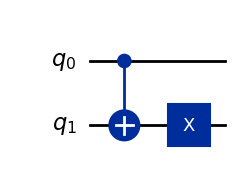

In [3]:
display(deutsch_function(3).draw(output="mpl"))

In [4]:
def compile_circuit(function: QuantumCircuit):
    # Compiles a circuit for use in Deutsch's algorithm.

    n = function.num_qubits - 1
    qc = QuantumCircuit(n + 1, n)

    qc.x(n)
    qc.h(range(n + 1))

    qc.barrier()
    qc.compose(function, inplace=True)
    qc.barrier()

    qc.h(range(n))
    qc.measure(range(n), range(n))

    return qc

The barriers are drawn to separate query gate from the rest of the circuit (since the query gate implementation is not too important)

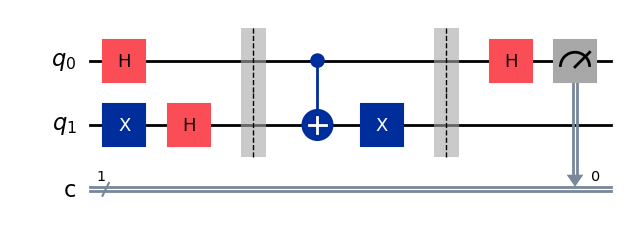

In [5]:
display(compile_circuit(deutsch_function(3)).draw(output="mpl"))

## Detuch's Problem:
 - Input: a function f : {0,1} -> {0,1}
 - Output: 0 if f is constant, 1 if f is balanced

In [6]:
def deutsch_algorithm(function: QuantumCircuit):
    # Determine if a one-bit function is constant or balanced.

    qc = compile_circuit(function)

    result = AerSimulator().run(qc, shots=1, memory=True).result()
    measurements = result.get_memory()
    if measurements[0] == "0":
        return "constant"
    return "balanced"

In [7]:
f = deutsch_function(3)
display(deutsch_algorithm(f))

'balanced'